In [1]:
##To predict whether a person has heart disease based on various health parameters, we can use a machine learning model.
#Below is an example of how to implement this using Python with the scikit-learn library.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('heart.csv')
#loading the dataset

In [4]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:

#EDA - foremost step is to understand the data and its distribution. 
# We can use various visualization techniques to explore the data.

In [6]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [7]:
df.shape
#918 -> rows and 12 -> columns

(918, 12)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [9]:
df.describe()
#only for the numerical columns

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [10]:
#Performing EDA and Data cleaning together

In [11]:
df.duplicated().sum()
#to check for duplicates in the dataset

0

In [12]:
df['HeartDisease'].value_counts()
#to check the distribution of the target variable
#this time, we have categorical target variable, that too equally distributed 

HeartDisease
1    508
0    410
Name: count, dtype: int64

Text(0, 0.5, 'Count')

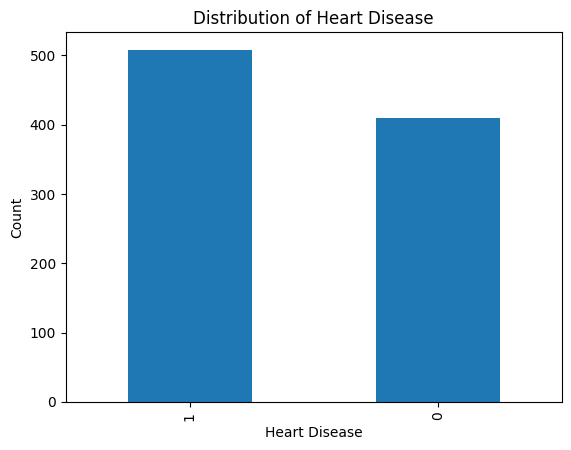

In [13]:
df['HeartDisease'].value_counts().plot(kind='bar')
plt.title('Distribution of Heart Disease')  
plt.xlabel('Heart Disease')
plt.ylabel('Count')

In [14]:
#to check for null values
df.isnull().sum()
#we can see there are no null values in the dataset

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [15]:
#Checking for numerical distribution

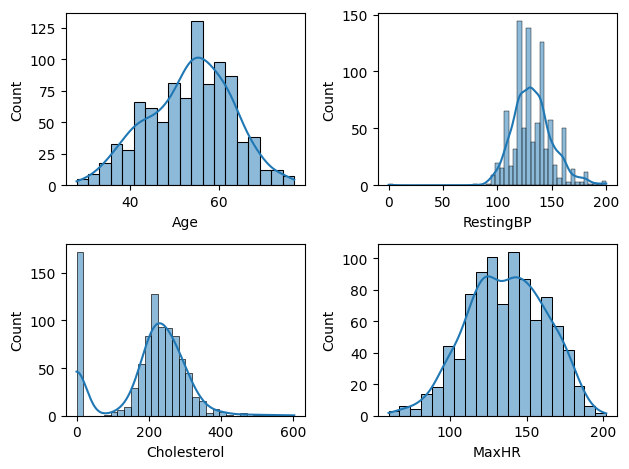

In [16]:
def plotting(var,num):
    plt.subplot(2,2,num) # 2 row, 2 column, num is the position of the plot
    sns.histplot(df[var], kde=True) #histplot is used to plot the histogram 
    #and kde is used to plot the kernel density estimation
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)
plt.tight_layout()


In [17]:
#age is finely distributed (not much skewed)
#but resting blood pressure is highly skewed, too much of outliers
#even it is showing that few person have resting BP of 0,
#which is not possible, so we need to handle those outliers and also the 0 values in the resting BP column
#For cholesterol, we can see that it is quitly normally distributed, but there are few outliers in the cholesterol column as well
#similarly there around 150+ people who have 0 cholesterol, which is not possible


In [18]:
#for resting BP, we can replace the 0 values with the mean value of the resting BP column
#for cholesterol, we can replace the 0 values with the mean value of the cholesterol column
ch_mean=df.loc[df['Cholesterol']!=0,'Cholesterol'].mean()
#this basically calculates the mean of the cholesterol column, but only for those rows where the cholesterol value is not 0
ch_mean


244.6353887399464

In [19]:
#now we will replace the 0 values in the cholesterol column with the mean value we just calculated
df['Cholesterol']=df['Cholesterol'].replace(0,ch_mean)

In [20]:
df['Cholesterol'].value_counts()

Cholesterol
244.635389    172
254.000000     11
223.000000     10
220.000000     10
230.000000      9
             ... 
392.000000      1
316.000000      1
153.000000      1
466.000000      1
131.000000      1
Name: count, Length: 222, dtype: int64

<AxesSubplot:xlabel='Cholesterol', ylabel='Count'>

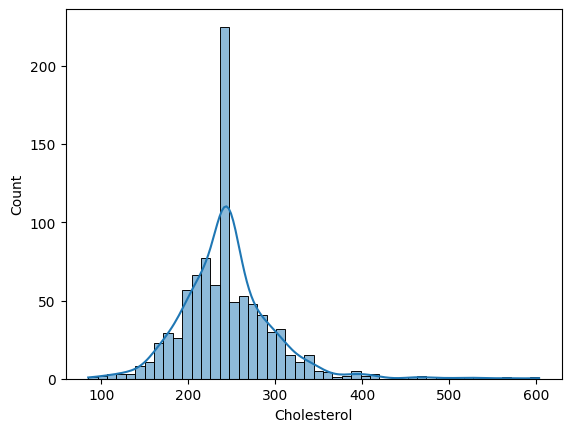

In [21]:
#plotting the histgram again for the cholesterol column to see
# the effect of replacing the 0 values with the mean value
sns.histplot(df['Cholesterol'], kde=True)


In [22]:
#for resting BP
resting_bp_mean=df.loc[df['RestingBP']!=0,'RestingBP'].mean()
resting_bp_mean

132.54089422028352

In [23]:
df['RestingBP']=df['RestingBP'].replace(0,resting_bp_mean)
df['RestingBP']=df['RestingBP'].round(2)

<AxesSubplot:xlabel='RestingBP', ylabel='Count'>

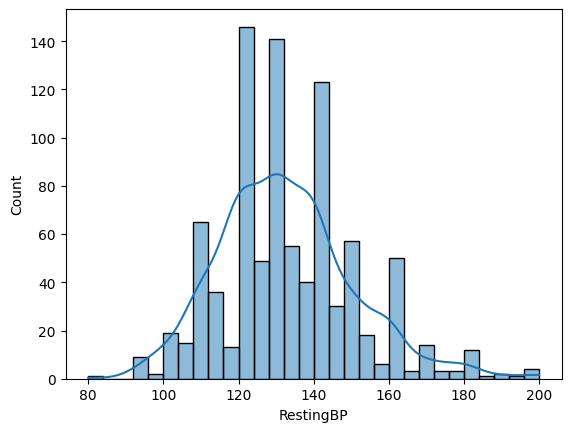

In [24]:
sns.histplot(df['RestingBP'], kde=True)


<AxesSubplot:xlabel='Sex', ylabel='count'>

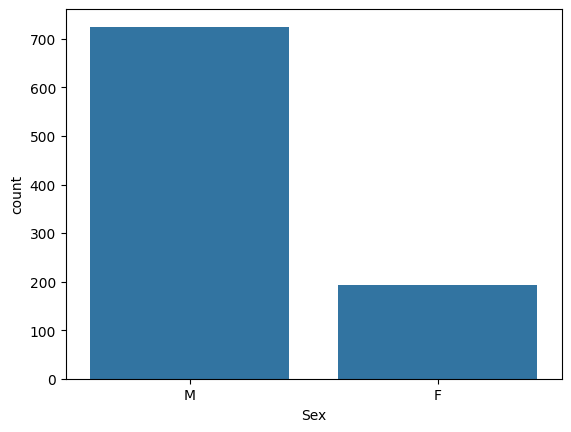

In [26]:
sns.countplot(x=df['Sex'])

<AxesSubplot:xlabel='ChestPainType', ylabel='count'>

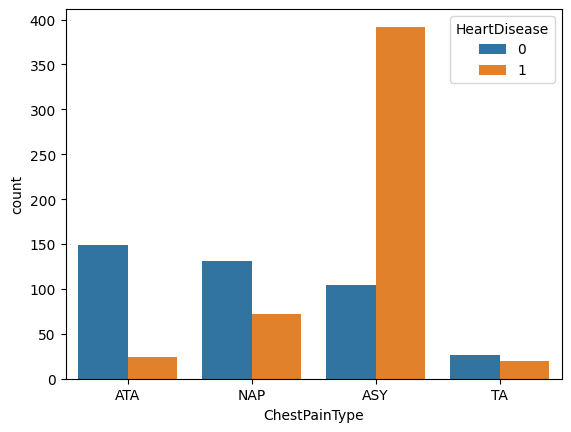

In [27]:
sns.countplot(x=df['ChestPainType'],hue=df['HeartDisease'])
#since the target feature is categorical, thus we can use hue to see the distribution of the target variable with respect to the chest pain type
#we can see through the visual that a person with ASY type of chest pain have higher chances of having heart disease
#wheresas for ATA type pain, it is less probable

<AxesSubplot:xlabel='Sex', ylabel='count'>

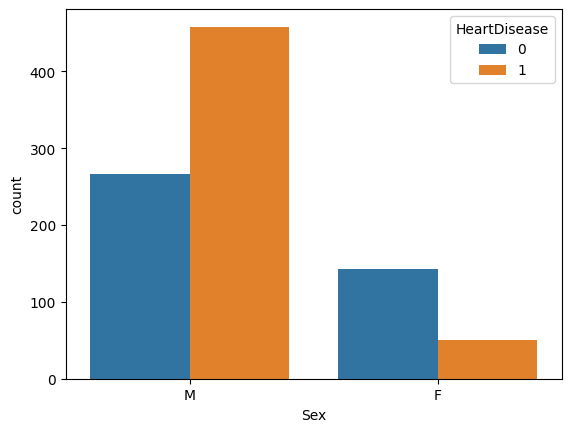

In [28]:
sns.countplot(x=df['Sex'],hue=df['HeartDisease'])

In [29]:
#Male having higher chances of having heart disease than female

<AxesSubplot:xlabel='FastingBS', ylabel='count'>

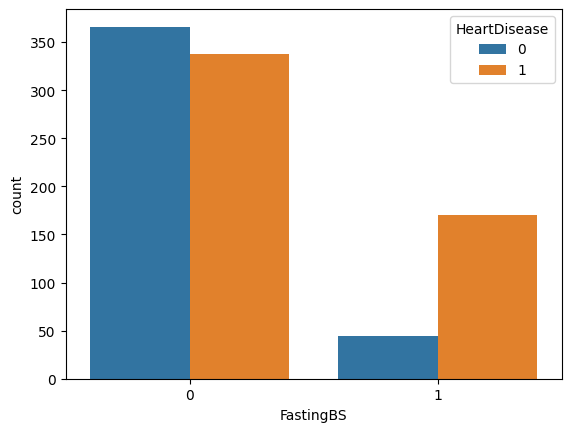

In [30]:
sns.countplot(x=df['FastingBS'],hue=df['HeartDisease'])

In [32]:
#to check for how many and which categorical features we have in the dataset
categorical_features=df.select_dtypes(include=['object']).columns
categorical_features

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')

<AxesSubplot:xlabel='HeartDisease', ylabel='Cholesterol'>

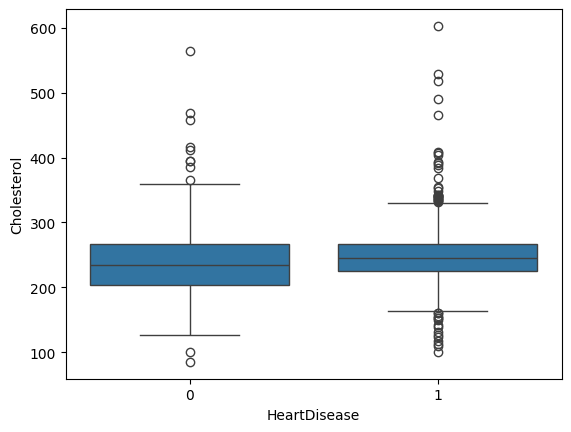

In [34]:
#comparing numerical features with categorical features using boxplot
sns.boxplot(x='HeartDisease',y='Cholesterol',data=df)

<AxesSubplot:xlabel='HeartDisease', ylabel='Age'>

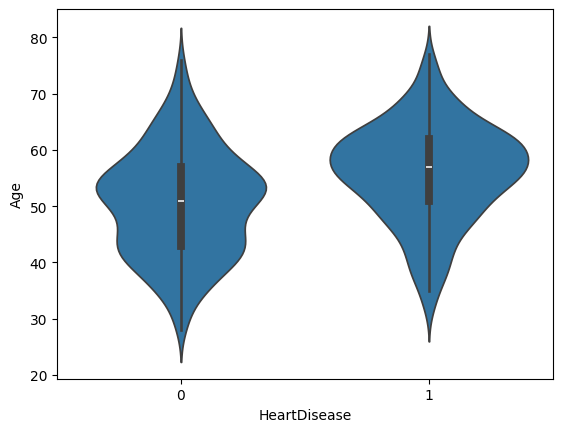

In [35]:
sns.violinplot(x='HeartDisease',y='Age',data=df)

<AxesSubplot:>

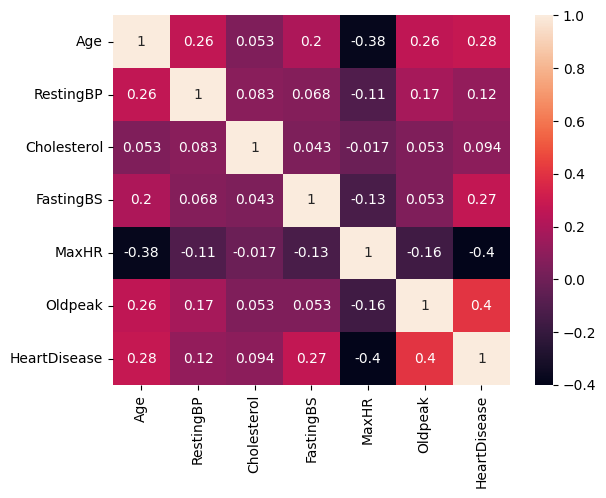

In [37]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [ ]:
#cholesterol is not having a good correlation with the target variable, thus we can drop the cholesterol column from the dataset
#But we can use the cholesterol column for EDA and then drop it before modeling, since it is not having a good correlation with the target variable, it might not be useful for the model and might even harm the performance of the model.

#Data pre-processing and cleaning 

In [40]:
df_encode=pd.get_dummies(df,drop_first=True)

In [41]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [42]:
#Through get_dummies, we have encoded the categorical features into numerical features, which can be used for modeling.
#now converting true/false values into 1/0 for the target variable

In [43]:
df_encode=df_encode.astype(int)

In [44]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1


In [45]:
#standard scaling
from sklearn.preprocessing import StandardScaler
numerical_col=['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']

In [46]:
scalar=StandardScaler()
df_encode[numerical_col]=scalar.fit_transform(df_encode[numerical_col])

In [47]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1
